In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
def find_optimal_harmful_detector(representations, labels, max_k=20, plot=True):
    """
    Implements harmful data detection EXACTLY as described in the paper.
    
    Paper formula: s_i = (1/k) * sum_{j=1}^{k} <z_i, v_j>^2
    """
    
    # Center the data (equation 4)
    mu = representations.mean(axis=0)
    Z_centered = representations - mu
    Z_centered = Z_centered.astype(np.float32)
    
    # SVD: Z = U Σ V^T (equation 4)
    U, sigma, VT = np.linalg.svd(Z_centered, full_matrices=False)
    
    # VT shape: (min(N,d), d) where VT[j] = v_{j+1}^T (0-indexed)
    # VT[0] is v_1^T, VT[1] is v_2^T, etc.
    
    # Try different numbers of components
    max_k = min(max_k, VT.shape[0])
    best_auc = 0
    best_k = 1
    auc_scores = []
    
    print("Testing different numbers of components...")
    for k in range(1, max_k + 1):
        # Get top k singular vectors
        V_k = VT[:k].T  # Shape: (d, k) - columns are v_1, v_2, ..., v_k
        
        # Compute projections: <z_i, v_j> for all i, j
        projections = np.dot(Z_centered, V_k)  # Shape: (N, k)
        
        # Compute filtering score (equation 7)
        # s_i = (1/k) * sum_{j=1}^{k} <z_i, v_j>^2
        scores = np.mean(projections ** 2, axis=1)  # Mean = sum/k
        
        # Calculate AUC
        auc = roc_auc_score(labels, scores)
        auc = max(auc, 1 - auc)
        auc_scores.append(auc)
        
        if auc > best_auc:
            best_auc = auc
            best_k = k
    
    print(f"\nBest number of components: {best_k}")
    print(f"Best AUC: {best_auc:.4f}")
    
    # Compute final scores with best k
    V_best = VT[:best_k].T
    projections = np.dot(Z_centered, V_best)
    scores = np.mean(projections ** 2, axis=1)
    
    # Find optimal threshold using Youden's J
    fpr, tpr, thresholds = roc_curve(labels, scores)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"\nOptimal threshold: {optimal_threshold:.2f}")
    print(f"TPR: {tpr[optimal_idx]:.3f}, FPR: {fpr[optimal_idx]:.3f}")
    
    # Predictions
    pred_is_harmful = scores > optimal_threshold
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(labels, pred_is_harmful).ravel()
    cm = pd.DataFrame(
        [[tp, fn], [fp, tn]],
        index=["Actual Harmful (1)", "Actual Safe (0)"],
        columns=["Pred Harmful (1)", "Pred Safe (0)"]
    )
    
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(labels, pred_is_harmful, target_names=['Safe', 'Harmful']))
    
    if plot:
        safe_scores = scores[labels == 0]
        harmful_scores = scores[labels == 1]
        
        fig = plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.plot(range(1, max_k + 1), auc_scores, marker='o')
        plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
        plt.xlabel('Number of Components')
        plt.ylabel('AUC Score')
        plt.title('AUC vs Number of Principal Components')
        plt.legend()
        plt.grid(alpha=0.3)
        
        plt.subplot(1, 3, 2)
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {best_auc:.3f})', linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
        plt.scatter(fpr[optimal_idx], tpr[optimal_idx], c='red', s=100, 
                   label=f'Optimal point', zorder=5)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.grid(alpha=0.3)
        
        plt.subplot(1, 3, 3)
        sns.kdeplot(safe_scores, color="blue", alpha=0.4, fill=True, label="Safe (0)")
        sns.kdeplot(harmful_scores, color="orange", alpha=0.4, fill=True, label="Harmful (1)")
        plt.axvline(x=optimal_threshold, color="red", linestyle="--", linewidth=2,
                   label=f"Threshold={optimal_threshold:.2f}")
        plt.xlabel(f"Filtering Score (k={best_k})")
        plt.ylabel("Density")
        plt.title(f"Score Distribution (AUC={best_auc:.3f})")
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    return {
        'best_k': best_k,
        'best_auc': best_auc,
        'optimal_threshold': optimal_threshold,
        'scores': scores,
        'predictions': pred_is_harmful,
        'VT': VT,
        'mu': mu,  # Save for applying to new data
        'metrics': {
            'tpr': tpr[optimal_idx],
            'fpr': fpr[optimal_idx],
            'confusion_matrix': cm,
            'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
        }
    }

Testing different numbers of components...

Best number of components: 20
Best AUC: 0.5997

Optimal threshold: 45.60
TPR: 1.000, FPR: 0.999

Confusion Matrix:
                    Pred Harmful (1)  Pred Safe (0)
Actual Harmful (1)              5191              3
Actual Safe (0)                11596              8

Classification Report:
              precision    recall  f1-score   support

        Safe       0.73      0.00      0.00     11604
     Harmful       0.31      1.00      0.47      5194

    accuracy                           0.31     16798
   macro avg       0.52      0.50      0.24     16798
weighted avg       0.60      0.31      0.15     16798



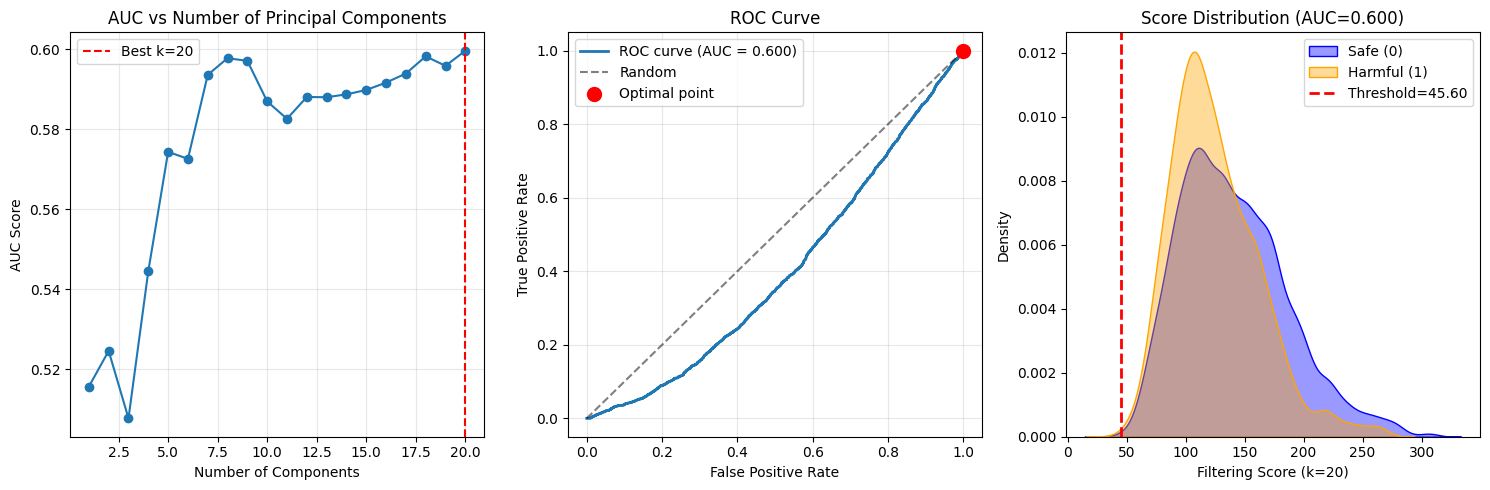


=== Final Results ===
Use 20 components
Use threshold = 45.60
Expected AUC = 0.5997


In [4]:
# Load data
benign_train = np.load('../data/tool_dataset/beavertails/full_reps/llama2-7b-chat-hf/30k/train/benign.npy')
harmful_train = np.load('../data/tool_dataset/beavertails/full_reps/llama2-7b-chat-hf/30k/train/harmful.npy')
benign_test = np.load('../data/tool_dataset/beavertails/full_reps/llama2-7b-chat-hf/30k/test/benign.npy')
harmful_test = np.load('../data/tool_dataset/beavertails/full_reps/llama2-7b-chat-hf/30k/test/harmful.npy')
harmful_train = harmful_train[:len(harmful_train)//3]
# Create labels (0 for benign, 1 for harmful)
y_train = np.concatenate([
    np.zeros(len(benign_train)),
    np.ones(len(harmful_train))
])
y_test = np.concatenate([
    np.zeros(len(benign_test)),
    np.ones(len(harmful_test))
])

# Stack features
X_train = np.vstack([benign_train, harmful_train])
X_test = np.vstack([benign_test, harmful_test])
# Find optimal detector
results = find_optimal_harmful_detector(X_train, y_train, max_k=20, plot=True)

# Access results
print(f"\n=== Final Results ===")
print(f"Use {results['best_k']} components")
print(f"Use threshold = {results['optimal_threshold']:.2f}")
print(f"Expected AUC = {results['best_auc']:.4f}")

# You can also use the results for new data
# new_scores = compute_scores_for_new_data(new_reps, results['VT'], results['best_k'])
# new_predictions = new_scores > results['optimal_threshold']